In [14]:
! pip install pycalphad scikit-learn numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 64.1 MB/s eta 0:00:00
  Installing build dependencies ... canceledERROR: Operation cancelled by user
^C


The `pycalphad` and `scikit-learn` libraries are now installed. The next cell configures the data and output directories, creating them if they don't exist.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# TDB Reverse-Engineering Pipeline — v2
Merged changes vs v1:
1. **TDB sanitizer + robust loader** (Cell 2b): 12 logged dialect repairs lift corpus coverage 9/28 → 21/28 files; mobility-only databases excluded; **byte-identical duplicates removed by sha256** (double-counting was shrinking consensus σ).
2. **Consensus**: `ddof=1`, per-TDB curves retained for provenance and honest LOTO CV.
3. **Heteroscedastic GP**: consensus σ enters as per-point noise `alpha = σ²/n`; new `predict_with_ensemble_noise()` separates latent-surface uncertainty from single-assessment scatter (the right std for DFT gating and LOTO coverage).
4. **RK fit corrected**: fit the *excess* after subtracting the endpoint (lattice-stability) baseline, σ-weighted, no division by x(1−x); targets reconstructed as baseline + excess.
5. Units: `svib_ht` is k_B/atom (S/R is dimensionless), labels fixed; phase alias `SIGMA` (not `SIGMA_SGTE`); element-in-phase-constituent check added.
Compute cost is unchanged or lower (dedup avoids redundant extractions; GP is still 1-D).

In [17]:
# CELL 1: CONFIG
import os
from pathlib import Path

DATA_DIR = os.environ.get("TDB_DATA_DIR", "/content/drive/MyDrive/CALPHAD_ML/data")
OUTPUT_DIR = os.environ.get("TDB_OUTPUT_DIR", "/content/drive/MyDrive/CALPHAD_ML/outputs")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR={DATA_DIR}  OUTPUT_DIR={OUTPUT_DIR}")

DATA_DIR=/content/drive/MyDrive/CALPHAD_ML/data  OUTPUT_DIR=/content/drive/MyDrive/CALPHAD_ML/outputs


In [19]:
# CELL 2: IMPORTS AND CONSTANTS
import copy
import glob
import hashlib
import re
import glob
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
import pycalphad

from pycalphad import Database, calculate
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

R_GAS = 8.314462618

SER_PHASE = {
    "CO": "HCP_A3", "CR": "BCC_A2", "NI": "FCC_A1", "FE": "BCC_A2",
    "AL": "FCC_A1", "TI": "HCP_A3", "MO": "BCC_A2", "W": "BCC_A2",
    "CU": "FCC_A1", "V": "BCC_A2", "MN": "BCC_A2", "NB": "BCC_A2",
    "TA": "BCC_A2", "RE": "HCP_A3", "RU": "HCP_A3",
    "C": "GRAPHITE", "HF": "HCP_A3", "ZR": "HCP_A3",
}
MAGNETIC_PARAM_TYPES = ("TC", "BMAGN", "NT", "BM", "BMAG", "CTA", "NTA")

In [20]:
# CELL 2b: TDB SANITIZER + ROBUST CORPUS LOADER
# Minimal, logged text repairs for Thermo-Calc-dialect constructs that
# pycalphad rejects. NOT a parser: all parsing is still pycalphad's.
# Empirically lifts this corpus from 9/28 to 21/28 loadable files.
#
#   R0  CRLF -> LF                          R8  strip control chars (\f etc.)
#   R1  drop ZEROVOLUME_ELEMENT (TC-only)   R9  '1768 Y;' -> '1768 Y'
#   R2  drop VS/V0 molar-volume params      R10 ' !.0E-4' typo -> ' 1.0E-4'
#   R3  dedupe FUNCTION/FUNCT by name       R11 '4.5E- 5' -> '4.5E-5'
#   R4  Fortran exponent '8.89+01'->E+01    R12 'MAGNETIC - 1' -> 'MAGNETIC -1'
#   R5  comment out free text between statements (headers, PARROT tables)
#   R6  leading-zero ints '+09800'->'+9800' R7  'N REF: 0' -> 'N REF0'
import hashlib, re, warnings

SAN_LOG = []
def _slog(name, rule, detail): SAN_LOG.append(f"[{name}] {rule}: {str(detail)[:70]}")

_KEYWORDS = ("ELEMENT","SPECIES","FUNCTION","FUNCT","TYPE_DEF","PHASE",
             "CONSTITUENT","PARAMETER","PARAM","PARA","DATABASE_INFO",
             "ASSESSED_SYSTEM","LIST_OF_REFERENCE","REFERENCE_FILE",
             "ADD_REF","DEFINE_SYSTEM","DEFAULT_COM","VERSION_DAT",
             "TEMPERATURE_LIM","TEMP_LIM","DIFFUSION","ZEROVOLUME","ELEMENTS")

def sanitize_tdb_text(text, name="?"):
    text = text.replace("\r\n","\n").replace("\r","\n")                     # R0
    n = len(re.findall(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", text))
    if n: _slog(name,"R8",f"{n} control chars")
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", "", text)               # R8
    n = len(re.findall(r"(\d(?:\.\d*)?\s+Y)\s*;", text))
    if n: _slog(name,"R9",f"{n}x 'Y;'")
    text = re.sub(r"(\d(?:\.\d*)?\s+Y)\s*;", r"\1", text)                  # R9
    n = len(re.findall(r"(\dE[+-])\s+(\d)", text))
    if n: _slog(name,"R11",f"{n}x broken exponent")
    text = re.sub(r"(\dE[+-])\s+(\d)", r"\1\2", text)                       # R11
    n = len(re.findall(r"(MAGNETIC\s+-)\s+(\d)", text))
    if n: _slog(name,"R12",f"{n}x AFM factor spacing")
    text = re.sub(r"(MAGNETIC\s+-)\s+(\d)", r"\1\2", text)                  # R12
    n = len(re.findall(r"(\s)!\.(\d)", text))
    if n: _slog(name,"R10",f"{n}x '!.0' typo")
    text = re.sub(r"(\s)!\.(\d)", r"\g<1>1.\2", text)                       # R10
    n = len(re.findall(r"\bREF:\s*", text))
    if n: _slog(name,"R7",f"{n}x 'REF:'")
    text = re.sub(r"\bREF:\s*(\S)", r"REF\1", text)                          # R7
    def _f4(m):
        _slog(name,"R4",m.group(0)); return m.group(1)+"E"+m.group(2)
    text = re.sub(r"(\d\.\d+)([+-]\d{1,2})(?=[\s,;!])", _f4, text)          # R4
    def _f6(m):
        _slog(name,"R6",m.group(0)); return m.group(1)+m.group(2)
    text = re.sub(r"([\s;,*/(+\-=])0+(\d)", _f6, text)                        # R6

    lines, out = text.split("\n"), []
    in_stmt = skip_blk = False
    vs_re  = re.compile(r"^\s*PARA(M(ETER)?)?\s+(VS|V0)\s*\(", re.I)
    zve_re = re.compile(r"^\s*ZEROVOLUME_ELEMENT", re.I)
    fn_re  = re.compile(r"^\s*FUNCT(ION)?\s+([A-Za-z0-9_]+)", re.I)
    seen = set()
    for ln in lines:
        s = ln.strip()
        if skip_blk:
            out.append("$ SANITIZED-CONT: "+ln)
            if "!" in ln: skip_blk = False
            continue
        if not in_stmt:
            if zve_re.match(ln):
                _slog(name,"R1",s); out.append("$ SANITIZED-R1: "+ln)
                if "!" not in ln: skip_blk = True
                continue
            if vs_re.match(ln):
                _slog(name,"R2",s); out.append("$ SANITIZED-R2: "+ln)
                if "!" not in ln: skip_blk = True
                continue
            m = fn_re.match(ln)
            if m:
                fn = m.group(2).upper()
                if fn in seen:
                    _slog(name,"R3",f"dup FUNCTION {fn}")
                    out.append("$ SANITIZED-R3: "+ln)
                    if "!" not in ln: skip_blk = True
                    continue
                seen.add(fn); out.append(ln); in_stmt = "!" not in ln; continue
            if s and not s.startswith("$"):
                kw = s.split()[0].upper().rstrip(",")
                if not any(kw.startswith(k) for k in _KEYWORDS):
                    _slog(name,"R5",s); out.append("$ SANITIZED-R5: "+ln); continue
            out.append(ln)
            if s and not s.startswith("$"): in_stmt = "!" not in ln
        else:
            out.append(ln)
            if "!" in ln: in_stmt = False
    return "\n".join(out)+"\n"

def try_load_tdb(fpath):
    """Database from raw file; on failure, sanitize text and retry.
    Returns (Database|None, status, error)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            return Database(fpath), "OK", None
        except Exception as e1:
            err1 = f"{type(e1).__name__}: {str(e1)[:120]}"
        try:
            raw = open(fpath, errors="ignore").read()
            clean = sanitize_tdb_text(raw, os.path.basename(fpath))
            return Database.from_string(clean, fmt="tdb"), "OK-SANITIZED", None
        except Exception as e2:
            return None, "FAIL", f"raw: {err1} | san: {type(e2).__name__}: {str(e2)[:120]}"

_KIN, _THERMO = {"MQ","MF","DQ","DF","VS","V0"}, {"G","L","TC","BMAGN","BM","NT"}

def classify_db(dbf):
    """'thermodynamic' | 'thermo+mobility' | 'mobility-only'."""
    pc = {}
    for p in dbf._parameters.all():
        pc[p.get("parameter_type","?")] = pc.get(p.get("parameter_type","?"),0)+1
    nk = sum(v for k,v in pc.items() if k in _KIN)
    nt = sum(v for k,v in pc.items() if k in _THERMO)
    return "mobility-only" if (nk and not nt) else ("thermo+mobility" if nk else "thermodynamic")

def load_corpus(data_dir):
    """Discover, dedupe (sha256), sanitize-load, and classify all TDBs.
    Returns list of dicts: {file, db, status, kind}. Skips mobility-only
    and byte-identical duplicates (these otherwise double-count in the
    consensus and artificially shrink sigma)."""
    files = []
    for ext in ("*.TDB","*.tdb","*.txt"):
        files.extend(glob.glob(os.path.join(data_dir,"**",ext), recursive=True))
    seen_sha, out = {}, []
    for fpath in sorted(set(files)):
        try: blob = open(fpath,"rb").read()
        except OSError: continue
        head = blob[:4000].decode(errors="ignore").upper()
        if "ELEMENT" not in head: continue          # screen non-TDB .txt
        sha = hashlib.sha256(blob).hexdigest()[:12]
        if sha in seen_sha:
            print(f"[DUP ] {os.path.basename(fpath)} == {seen_sha[sha]} (skipped)")
            continue
        seen_sha[sha] = os.path.basename(fpath)
        db, status, err = try_load_tdb(fpath)
        if db is None:
            print(f"[FAIL] {os.path.basename(fpath)}: {err}")
            continue
        kind = classify_db(db)
        if kind == "mobility-only":
            print(f"[KIN ] {os.path.basename(fpath)}: mobility-only, excluded")
            continue
        print(f"[{status:>4.4s}] {os.path.basename(fpath)} ({kind})")
        out.append({"file": fpath, "db": db, "status": status, "kind": kind, "sha": sha})
    return out


In [21]:
# CELL 3: TARGET EXTRACTION MODULE
import numpy as np
# Unit Conversion Factor: 1 eV/atom = 96485.3321 J/mol-atom
J_TO_EV = 1.0 / 96485.3321

def resolve_phase(dbf, base):
    cands = {p.upper(): p for p in dbf.phases}
    aliases = {
        "FCC_A1": ["FCC_A1", "FCC", "A1"],
        "BCC_A2": ["BCC_A2", "BCC", "A2"],
        "HCP_A3": ["HCP_A3", "HCP", "A3"],
        "LIQUID": ["LIQUID", "LIQ", "L"],
        "SIGMA":  ["SIGMA", "SIGMA1", "SIG"],
    }.get(base, [base])
    for a in aliases:
        if a in cands: return cands[a]
    for pu, p in cands.items():
        if pu.startswith(base) and base != "LIQUID": return p
    return None

def strip_magnetic(dbf):
    db2 = copy.deepcopy(dbf)
    try:
        docs = [d.doc_id for d in db2._parameters.all() if d.get("parameter_type") in MAGNETIC_PARAM_TYPES]
        if docs: db2._parameters.remove(doc_ids=docs)
    except Exception as e:
        raise RuntimeError(f"magnetic strip failed: {e}")
    return db2

def _phase_layout(dbf, phase, comps):
    ph = dbf.phases[phase]
    sites = [float(s) for s in ph.sublattices]
    layout = []
    for sl in (ph.constituents or []):
        names = sorted(str(c).upper() for c in sl)
        active = [c for c in names if c in comps]
        layout.append(active)
    return sites, layout

def _classify(layout, els):
    A, B = els
    for sl in layout:
        non_va = [c for c in sl if c != "VA"]
        if len(non_va) == 0 or len(non_va) == 1 or (A in non_va and B in non_va and len(non_va) == 2): continue
        return "envelope"
    pure_els = set()
    has_mix = False
    for sl in layout:
        non_va = [c for c in sl if c != "VA"]
        if len(non_va) == 1: pure_els.add(non_va[0])
        elif len(non_va) == 2: has_mix = True
    return "envelope" if pure_els else ("exact" if has_mix else "envelope")

def _points_disordered(sites, layout, els, x_grid):
    A, B = els
    width = sum(len(sl) for sl in layout)
    pts = np.zeros((len(x_grid), width))
    sconf, natoms = np.zeros(len(x_grid)), np.zeros(len(x_grid))
    for k, x in enumerate(x_grid):
        off, s_form, n_at = 0, 0.0, 0.0
        for a_s, sl in zip(sites, layout):
            ys = np.zeros(len(sl))
            non_va = [c for c in sl if c != "VA"]
            if len(non_va) == 0: ys[sl.index("VA")] = 1.0
            elif len(non_va) == 1:
                ys[sl.index(non_va[0])] = 1.0
                n_at += a_s
            else:
                eps = 1e-12
                xa = min(max(1.0 - x, eps), 1.0 - eps)
                xb = 1.0 - xa
                ys[sl.index(A)], ys[sl.index(B)] = xa, xb
                if "VA" in sl: ys[sl.index("VA")] = 0.0
                s_form += -R_GAS * a_s * (xa * np.log(xa) + xb * np.log(xb))
                n_at += a_s
            pts[k, off:off + len(sl)] = ys
            off += len(sl)
        sconf[k] = s_form / n_at if n_at > 0 else np.nan
        natoms[k] = n_at
    return pts, sconf, natoms

def _gm_at_points(dbf, comps, phase, T, pts):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = calculate(dbf, comps, phase, T=float(T), P=101325, N=1, points=pts, output="GM")
    return np.asarray(res.GM).reshape(-1)

def _gm_envelope(dbf, comps, phase, T, els, x_grid, pdens, seed):
    np.random.seed(seed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = calculate(dbf, comps, phase, T=float(T), P=101325, N=1, pdens=pdens, output="GM")
    gm = np.asarray(res.GM).reshape(-1)
    x2 = np.asarray(res.X.sel(component=els[1])).reshape(-1)
    Y = np.asarray(res.Y).reshape(-1, np.asarray(res.Y).shape[-1])
    sites, layout = _phase_layout(dbf, phase, set(comps))
    nx = len(x_grid)
    gm_o, sc_o = np.full(nx, np.nan), np.full(nx, np.nan)
    half = 0.5 * (x_grid[1] - x_grid[0]) if nx > 1 else 0.5
    for i, xc in enumerate(x_grid):
        m = (x2 >= xc - half) & (x2 < xc + half)
        if not m.any(): continue
        idx = np.flatnonzero(m)
        j = idx[np.argmin(gm[idx])]
        gm_o[i] = gm[j]
        y = Y[j]
        off, s_form, n_at = 0, 0.0, 0.0
        for a_s, sl in zip(sites, layout):
            ys = np.clip(y[off:off + len(sl)], 1e-14, 1.0)
            off += len(sl)
            s_form += -R_GAS * a_s * float(np.sum(ys * np.log(ys)))
            for c, yc in zip(sl, ys):
                if c != "VA": n_at += a_s * float(yc)
        sc_o[i] = s_form / n_at if n_at > 0 else np.nan
    return gm_o, sc_o

def _ser_reference_H(dbf, el, T, dT=2.0):
    ser = resolve_phase(dbf, SER_PHASE.get(el, "___"))
    if ser is None: raise ValueError(f"SER phase for {el} absent in database")
    comps = [el, "VA"]
    sites, layout = _phase_layout(dbf, phase=ser, comps=set(comps))
    width = sum(len(sl) for sl in layout)
    pt = np.zeros((1, width))
    off = 0
    for sl in layout:
        ys = np.zeros(len(sl))
        if el in sl: ys[sl.index(el)] = 1.0
        elif "VA" in sl: ys[sl.index("VA")] = 1.0
        pt[0, off:off + len(sl)] = ys; off += len(sl)
    g = {t: float(_gm_at_points(dbf, comps, ser, t, pt)[0]) for t in (T - dT, T, T + dT)}
    return g[T] + T * -(g[T + dT] - g[T - dT]) / (2 * dT)

def extract_targets(dbf, els, base_phase, x_grid=None, T0=298.15, T_hi=1000.0, dT=2.0, pdens=4000, seed=0):
    if x_grid is None: x_grid = np.linspace(0.0, 1.0, 26)
    x_grid = np.asarray(x_grid, float)
    phase = resolve_phase(dbf, base_phase)
    if phase is None: raise KeyError(f"phase {base_phase} not found")
    comps = sorted(set(els) | {"VA"})
    sites, layout = _phase_layout(dbf, phase, set(comps))
    mode = _classify(layout, els)
    db_nomag = strip_magnetic(dbf)

    if mode == "exact":
        pts, sconf, _ = _points_disordered(sites, layout, els, x_grid)
        gm = {t: _gm_at_points(dbf, comps, phase, t, pts) for t in (T0 - dT, T0, T0 + dT)}
        gmn = {t: _gm_at_points(db_nomag, comps, phase, t, pts) for t in (T_hi - dT, T_hi + dT)}
        sconf_hi = sconf
    else:
        gm = {t: _gm_envelope(dbf, comps, phase, t, els, x_grid, pdens, seed)[0] for t in (T0 - dT, T0, T0 + dT)}
        g_lo, _ = _gm_envelope(db_nomag, comps, phase, T_hi - dT, els, x_grid, pdens, seed)
        g_hi, sconf_hi = _gm_envelope(db_nomag, comps, phase, T_hi + dT, els, x_grid, pdens, seed)
        gmn = {T_hi - dT: g_lo, T_hi + dT: g_hi}

    s_T0 = -(gm[T0 + dT] - gm[T0 - dT]) / (2 * dT)
    h_T0 = gm[T0] + T0 * s_T0
    h_ser = {el: _ser_reference_H(dbf, el, T0, dT) for el in els}
    e_form_joules = h_T0 - ((1 - x_grid) * h_ser[els[0]] + x_grid * h_ser[els[1]])
    e_form_ev = e_form_joules * J_TO_EV # Convert to eV/atom

    s_nomag = -(gmn[T_hi + dT] - gmn[T_hi - dT]) / (2 * dT)
    svib_ht_joules = s_nomag - sconf_hi
    svib_ht_kBT = svib_ht_joules / R_GAS # Convert to kBT

    s_conf_kBT = sconf_hi / R_GAS # Convert to kBT

    return {"x": x_grid, "E_form": e_form_ev, "svib_ht": svib_ht_kBT, "s_conf": s_conf_kBT,
            "phase_resolved": phase, "mode": mode, "meta": {"T0": T0, "T_hi": T_hi, "els": list(els),
                     "units": {"E_form": "eV/atom", "svib_ht": "kB/atom"}}}

In [22]:
# CELL 4: CONSENSUS AND SURROGATE ML LAYER
# Changes vs v1: (i) ddof=1 for small-N sigma; (ii) per-TDB curves kept in
# the consensus object (needed for honest LOTO CV and provenance);
# (iii) heteroscedastic GP — consensus sigma enters as per-point noise
# alpha = sigma^2/n (variance of the consensus MEAN), so the surrogate is
# less confident exactly where the TDB ensemble disagrees. Negligible
# extra compute (same 1-D GP).
def build_consensus(target_outputs: List[Dict]) -> Dict:
    if not target_outputs: return {}
    x_grid = target_outputs[0]["x"]
    e_forms = np.array([t["E_form"] for t in target_outputs])
    svibs = np.array([t["svib_ht"] for t in target_outputs])
    nE = np.sum(~np.isnan(e_forms), axis=0)
    nS = np.sum(~np.isnan(svibs), axis=0)
    with np.errstate(all="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        cons = {
            "x": x_grid.tolist(),
            "E_form": {"mean": np.nanmean(e_forms, axis=0).tolist(),
                       "sigma": np.nanstd(e_forms, axis=0, ddof=1).tolist(),
                       "n_contributing": nE.tolist()},
            "svib_ht": {"mean": np.nanmean(svibs, axis=0).tolist(),
                        "sigma": np.nanstd(svibs, axis=0, ddof=1).tolist(),
                        "n_contributing": nS.tolist()},
            "curves": {"E_form": e_forms.tolist(), "svib_ht": svibs.tolist(),
                       "sources": [t.get("source","?") for t in target_outputs]},
            "meta": {"T0": target_outputs[0]["meta"]["T0"],
                     "T_hi": target_outputs[0]["meta"]["T_hi"],
                     "els": target_outputs[0]["meta"]["els"],
                     "phase_name": target_outputs[0]["phase_resolved"],
                     "units": {"E_form": "eV/atom", "svib_ht": "kB/atom"}}}
    return cons

class ConsensusGPSurrogate:
    """1-D heteroscedastic GP over the consensus mean.

    Noise model: alpha_i = sigma_i^2 / n_i  (std error of the consensus
    mean) + small jitter; a bounded WhiteKernel mops up residual
    misspecification. predict() returns std of the latent consensus
    surface; use predict_with_ensemble_noise() when comparing a SINGLE
    new TDB/DFT value against the ensemble (adds back sigma^2)."""
    def __init__(self):
        self.kernel = (ConstantKernel(1.0, (1e-4, 1e4))
                       * RBF(0.3, (5e-2, 5.0))
                       + WhiteKernel(1e-4, (1e-8, 1e-1)))
        self._sig_interp = None

    def _fit_one(self, X, y, alpha):
        gp = GaussianProcessRegressor(kernel=self.kernel, alpha=alpha,
                                      n_restarts_optimizer=5,
                                      normalize_y=True, random_state=42)
        gp.fit(X, y)
        return gp

    def fit(self, cons: Dict):
        X = np.array(cons["x"]).reshape(-1, 1)
        for key, attr in (("E_form","gp_e_form"), ("svib_ht","gp_svib")):
            mu = np.array(cons[key]["mean"])
            sg = np.array(cons[key]["sigma"])
            n  = np.maximum(np.array(cons[key]["n_contributing"]), 1)
            ok = ~np.isnan(mu)
            sg_ok = np.where(np.isnan(sg[ok]) | (sg[ok] <= 0),
                             np.nanmedian(sg[ok]) if np.any(sg[ok] > 0) else 1e-3,
                             sg[ok])
            alpha = (sg_ok**2 / n[ok]) + 1e-10
            setattr(self, attr, self._fit_one(X[ok], mu[ok], alpha))
        # keep ensemble sigma for z-scoring single observations
        sgE = np.array(cons["E_form"]["sigma"]); xs = np.array(cons["x"])
        okE = ~np.isnan(sgE)
        self._sig_interp = (xs[okE], sgE[okE])
        return self

    def predict(self, x_query: np.ndarray):
        X_q = np.asarray(x_query).reshape(-1, 1)
        mean_e, std_e = self.gp_e_form.predict(X_q, return_std=True)
        mean_s, std_s = self.gp_svib.predict(X_q, return_std=True)
        return mean_e, std_e, mean_s, std_s

    def ensemble_sigma(self, x_query: np.ndarray):
        xs, sg = self._sig_interp
        return np.interp(np.asarray(x_query).reshape(-1), xs, sg)

    def predict_with_ensemble_noise(self, x_query: np.ndarray):
        """Predictive std for a SINGLE new assessment/DFT value: latent
        GP variance + cross-TDB ensemble variance (in quadrature)."""
        mean_e, std_e, mean_s, std_s = self.predict(x_query)
        se = self.ensemble_sigma(x_query)
        return mean_e, np.sqrt(std_e**2 + se**2), mean_s, std_s

def leave_one_tdb_out_cv(all_tdb_targets: List[Dict]):
    """Hold out one TDB curve; fit on the rest; report MAE and the
    fraction of held-out points inside the 2-sigma predictive band
    (with ensemble noise — the held-out curve is one draw from the
    assessment distribution, so latent-only std would under-cover)."""
    mae_l, cov_l = [], []
    for i in range(len(all_tdb_targets)):
        held = all_tdb_targets[i]
        rest = all_tdb_targets[:i] + all_tdb_targets[i+1:]
        if len(rest) < 2: continue
        surr = ConsensusGPSurrogate().fit(build_consensus(rest))
        y_true = np.array(held["E_form"]); x = np.array(held["x"])
        ok = ~np.isnan(y_true)
        if not np.any(ok): continue
        mu, sd, _, _ = surr.predict_with_ensemble_noise(x[ok])
        mae_l.append(np.mean(np.abs(y_true[ok] - mu)))
        cov_l.append(np.mean(np.abs(y_true[ok] - mu) <= 2 * sd))
    return (np.mean(mae_l) if mae_l else np.nan,
            np.mean(cov_l) if cov_l else np.nan)


In [23]:
# CELL 5: APPLICATION DEMOS & PLOTTING
def demo_b_dft_gating(surrogate: ConsensusGPSurrogate, system_name: str, out_path: str):
    x_grid = np.linspace(0, 1, 100)
    # gating compares a SINGLE DFT value vs the ensemble -> include
    # cross-TDB scatter in the predictive std, not just latent GP std
    mean_e, std_e, _, _ = surrogate.predict_with_ensemble_noise(x_grid)

    x_test = 0.5
    true_mean, true_std, _, _ = surrogate.predict_with_ensemble_noise(np.array([x_test]))
    good_dft = true_mean[0] + 0.1 * true_std[0]
    bad_dft = true_mean[0] + 4.5 * true_std[0]

    z_score_bad = np.abs(bad_dft - true_mean[0]) / true_std[0]

    plt.figure(figsize=(8,5))
    plt.plot(x_grid, mean_e, 'b-', label='GP Consensus $E_{form}$')
    plt.fill_between(x_grid, mean_e - 2*std_e, mean_e + 2*std_e, color='blue', alpha=0.2, label='$\pm 2\sigma$ Epistemic Uncertainty')

    plt.scatter([x_test], [good_dft], color='green', marker='o', s=100, label='Converged SQS DFT')
    plt.scatter([x_test], [bad_dft], color='red', marker='x', s=100, label=f'Outlier SQS DFT (z={z_score_bad:.1f})')

    plt.title(f"Use Case B: DFT Gating via GP Surrogate ({system_name})")
    plt.xlabel("Mole Fraction")
    plt.ylabel("$E_{form}$ (eV/atom)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()

def demo_d_bayesian_ensemble(x_grid, candidate_g_curves, surrogate_mean, surrogate_std, out_path: str):
    log_likelihoods = []
    for curve in candidate_g_curves:
        ll = np.sum(-0.5 * ((curve - surrogate_mean) / surrogate_std)**2)
        log_likelihoods.append(ll)

    log_likelihoods = np.array(log_likelihoods)
    log_likelihoods -= np.max(log_likelihoods)
    weights = np.exp(log_likelihoods) / np.sum(np.exp(log_likelihoods))

    ensemble_g = np.average(candidate_g_curves, axis=0, weights=weights)
    ensemble_std = np.sqrt(np.average((candidate_g_curves - ensemble_g)**2, axis=0, weights=weights))

    plt.figure(figsize=(8,5))
    for i, curve in enumerate(candidate_g_curves):
        plt.plot(x_grid, curve, color='gray', alpha=0.3, label='Candidate TDB' if i==0 else "")

    plt.plot(x_grid, ensemble_g, 'k--', linewidth=2, label='Bayesian Ensemble Mean')
    plt.fill_between(x_grid, ensemble_g - 2*ensemble_std, ensemble_g + 2*ensemble_std, color='black', alpha=0.2)
    plt.title("Use Case D: Bayesian-Weighted Ensemble Output")
    plt.xlabel("Mole Fraction")
    plt.ylabel("$E_{form}(x)$ (eV/atom)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()

def plot_consensus_with_curves(consensus_data, out_path):
    """Per-TDB curves + consensus mean ± 2σ (deliverable 5a)."""
    x = np.array(consensus_data["x"])
    curves = np.array(consensus_data["curves"]["E_form"])
    mu = np.array(consensus_data["E_form"]["mean"])
    sg = np.array(consensus_data["E_form"]["sigma"])
    plt.figure(figsize=(8, 5))
    for i, c in enumerate(curves):
        plt.plot(x, c, color="gray", alpha=0.45, lw=1,
                 label="Individual TDBs" if i == 0 else "")
    plt.plot(x, mu, "b-", lw=2, label="Consensus mean")
    plt.fill_between(x, mu - 2 * sg, mu + 2 * sg, color="blue", alpha=0.15,
                     label="±2σ (cross-TDB)")
    m = consensus_data["meta"]
    plt.title(f"Consensus E_form: {m['els'][0]}-{m['els'][1]} {m['phase_name']} "
              f"(n={int(np.nanmax(consensus_data['E_form']['n_contributing']))} TDBs)")
    plt.xlabel(f"x({m['els'][1]})"); plt.ylabel("$E_{form}$ (eV/atom)")
    plt.legend(); plt.tight_layout(); plt.savefig(out_path); plt.show()


<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1445/989645788.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x_grid, mean_e - 2*std_e, mean_e + 2*std_e, color='blue', alpha=0.2, label='$\pm 2\sigma$ Epistemic Uncertainty')


[  OK] Co-Cr-C - 2014-05-30.TDB (thermodynamic)
[KIN ] Co-Cr-W-K.TDB: mobility-only, excluded
[OK-S] Enriched dataseTDB_V2.txt (thermodynamic)
[  OK] co-cr-ti.TDB (thermodynamic)
[  OK] mmc7.tdb (thermodynamic)
[  OK] CoCrFeNiV.TDB-R3.txt (thermodynamic)
[OK-S] AlCoCrNi-2016Gheno.TDB (thermodynamic)
[  OK] AlCoCrNi-2016Liu.TDB (thermo+mobility)
[OK-S] CORRECTdatabase.txt (thermodynamic)
[DUP ] Enriched dataseTDB_V2.txt == Enriched dataseTDB_V2.txt (skipped)
[FAIL] NIST-NiMob13.TDB: raw: ParseException: Invalid TDB syntax.
    PARA VS(LIQUID) 0 1.0E-5; 3.00E+3 N 
                    ^, found '0'  (at char 1512), (line:68, | san: TypeError: '<' not supported between instances of 'TemperatureType' and 'str'
[DUP ] mmc1.TDB == AlCoCrNi-2016Liu.TDB (skipped)
[KIN ] AlFeTi-2014Chen-Mobility.tdb: mobility-only, excluded
[OK-S] CONIGA.TDB (thermodynamic)
[OK-S] Cu-Co-Ni-full.tdb (thermo+mobility)
[  OK] Co-Mo-Ni.TDB (thermodynamic)
[  OK] Mo-Ni-W.TDB (thermodynamic)
[KIN ] NI-CO-RE diffusion c

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


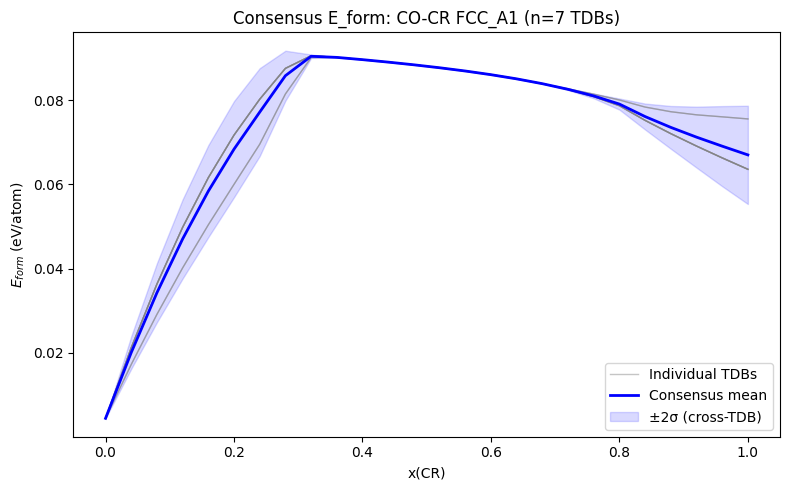

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_g

Leave-One-TDB-Out CV MAE: 0.0019 eV/atom
Leave-One-TDB-Out 2-sigma coverage: 92.3% (nominal ~95%)

--- Generating Demos ---


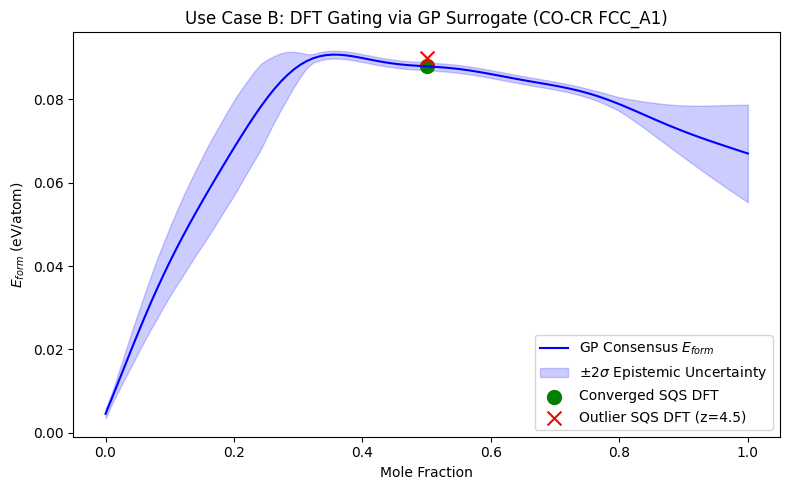

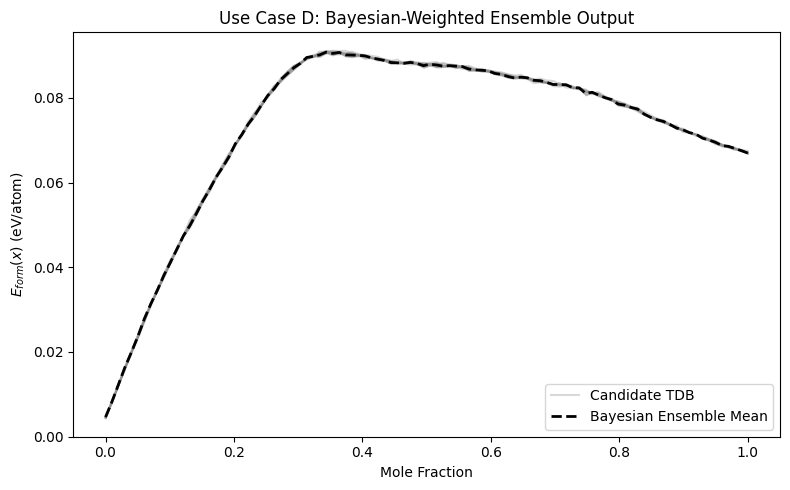


Pipeline execution complete. Plots saved to /content/drive/MyDrive/CALPHAD_ML/outputs.


In [27]:
# CELL 6: MAIN EXECUTION PIPELINE
def main():
    global consensus_data, surrogate  # used by RK cells below
    # Sanitize-load, dedupe, and classify the whole corpus once
    corpus = load_corpus(DATA_DIR)
    print(f"\nUsable thermodynamic databases: {len(corpus)}")

    elements = ("CO", "CR")
    phase_name = "FCC_A1"   # alias-resolvable base name (was SIGMA_SGTE)

    target_outputs = []
    print(f"\n--- Extracting Targets for {elements} in {phase_name} ---")

    for entry in corpus:
        fname = os.path.basename(entry["file"])
        dbf = entry["db"]
        try:
            if not all(el in dbf.elements for el in elements): continue
            resolved_phase = resolve_phase(dbf, phase_name)
            if resolved_phase is None: continue
            # the phase must actually model BOTH elements in its sublattices
            consts = set(str(c).upper() for sl in
                         (dbf.phases[resolved_phase].constituents or [])
                         for c in sl)
            if not set(elements) <= consts: continue
            targets = extract_targets(dbf, elements, resolved_phase)
            if np.all(np.isnan(targets["E_form"])): continue
            targets["source"] = fname
            target_outputs.append(targets)
            print(f"[OK] {fname} -> {resolved_phase} ({targets['mode']})")
        except Exception as e:
            print(f"[SKIP] {fname} ({type(e).__name__}: {str(e)[:60]})")

    if not target_outputs:
        print("\nError: No valid databases found for this system/phase combination.")
        return

    # Build Consensus
    print("\n--- Building Consensus ---")
    consensus_data = build_consensus(target_outputs)
    # Now that phase_name is in meta, we can get it from consensus_data
    actual_elements = consensus_data['meta']['els']
    actual_phase_name = consensus_data['meta']['phase_name']
    cons_filename = f"{actual_elements[0]}_{actual_elements[1]}_{actual_phase_name}_consensus.json"
    cons_path = os.path.join(OUTPUT_DIR, cons_filename)
    with open(cons_path, 'w') as f:
        json.dump(consensus_data, f, indent=2)
    print(f"Saved consensus data to {cons_path}")

    # ML Surrogate and CV
    print("\n--- Fitting ML Surrogate ---")
    surrogate = ConsensusGPSurrogate().fit(consensus_data)

    consensus_plot_path = os.path.join(
        OUTPUT_DIR, f"consensus_{actual_elements[0]}-{actual_elements[1]}_{actual_phase_name}.png")
    plot_consensus_with_curves(consensus_data, consensus_plot_path)

    if len(target_outputs) > 2: # LOTO needs >=3 so each fold keeps >=2
        mae, coverage = leave_one_tdb_out_cv(target_outputs)
        print(f"Leave-One-TDB-Out CV MAE: {mae:.4f} eV/atom")
        print(f"Leave-One-TDB-Out 2-sigma coverage: {coverage*100:.1f}% (nominal ~95%)")
    else:
        print("Skipping Leave-One-Out CV: Only one (or zero) valid databases found.")


    # Demos
    print("\n--- Generating Demos ---")
    demo_b_filename = f"demo_B_{actual_elements[0]}-{actual_elements[1]}_{actual_phase_name}.png"
    demo_b_path = os.path.join(OUTPUT_DIR, demo_b_filename)
    demo_b_dft_gating(surrogate, f"{actual_elements[0]}-{actual_elements[1]} {actual_phase_name}", demo_b_path)

    x_grid = np.linspace(0, 1, 100)
    mean_e, std_e, _, _ = surrogate.predict(x_grid)

    # Create 5 synthetic candidates based on the consensus
    np.random.seed(42)
    synthetic_candidates = []
    for _ in range(5):
        noise = np.random.normal(0, np.mean(std_e) * 0.5, size=len(x_grid))
        bias = np.sin(x_grid * np.pi) * np.mean(std_e) * (np.random.rand() - 0.5)
        synthetic_candidates.append(mean_e + bias + noise)

    demo_d_filename = f"demo_D_{actual_elements[0]}-{actual_elements[1]}_{actual_phase_name}.png"
    demo_d_path = os.path.join(OUTPUT_DIR, demo_d_filename)
    demo_d_bayesian_ensemble(x_grid, synthetic_candidates, mean_e, std_e, demo_d_path)

    print(f"\nPipeline execution complete. Plots saved to {OUTPUT_DIR}.")

# Execute Pipeline
main()

### Redlich-Kister Polynomial Fitting (corrected: fit the *excess*, not the raw curve)

The RK expansion describes the **excess** part of a property:
$$ P^{ex}(x) = x_A x_B \sum_{i=0}^{n} L_i\,(x_A - x_B)^i $$

The extracted `E_form(x)` is referenced to the **SER** states, so for any phase that is not the SER phase of both elements its endpoints are **non-zero** (lattice-stability terms, e.g. FCC-Cr $\approx +0.07$ eV/atom; SIGMA endmembers are far larger). Likewise `svib_ht(x)` is an **absolute** entropy ($\sim 7\,k_B$/atom), not an excess.

Dividing the raw curve by $x_A x_B$ therefore diverges at the endpoints and corrupts the fit (verified: on synthetic data with $E(0){=}0.07$, the naive fit returns $L_0=+0.16$ for a true $L_0=-0.12$). The correct procedure:

1. subtract the endpoint baseline $\;P^{lin}(x) = (1-x)P(0) + xP(1)$,
2. fit $P^{ex} = P - P^{lin}$ by **weighted** least squares on the design matrix $[\,x_Ax_B,\;x_Ax_B(x_A{-}x_B),\dots]$ with weights $1/\sigma^2(x)$ from the consensus (no division by $x_Ax_B$),
3. when reconstructing DFT targets, report **baseline + excess** — ATAT/sqs2tdb compares total formation quantities vs SER, and the endpoint terms *are* part of the target.

In [28]:
# CELL 7: REDLICH-KISTER FIT OF CONSENSUS (excess-corrected, sigma-weighted)
def fit_rk_excess(x, y, sigma=None, order=2):
    """Weighted LSQ RK fit of the EXCESS of y(x).
    Returns (L[0..order-1], (y0, y1)) where y0,y1 are the endpoint
    (lattice-stability / absolute-entropy) baseline values."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = ~np.isnan(y)
    x, y = x[ok], y[ok]
    sg = None if sigma is None else np.asarray(sigma, float)[ok]
    # Phases with restricted sublattice models (e.g. SIGMA) only cover part
    # of [0,1]. The baseline is the chord through the COVERED endpoints
    # (xlo, xhi); the fit and any reconstruction are only valid on
    # [xlo, xhi] — do NOT extrapolate a CEF phase beyond its model range.
    xlo, xhi = x.min(), x.max()
    ylo, yhi = y[np.argmin(x)], y[np.argmax(x)]
    t = (x - xlo) / (xhi - xlo)
    exc = y - ((1 - t) * ylo + t * yhi)
    M = np.column_stack([x * (1 - x) * (1 - 2 * x) ** i for i in range(order)])
    if sg is not None:
        w = 1.0 / np.maximum(sg, np.nanmedian(sg[sg > 0]) * 1e-2 + 1e-12) ** 2
    else:
        w = np.ones_like(x)
    sw = np.sqrt(w)
    L, *_ = np.linalg.lstsq(M * sw[:, None], exc * sw, rcond=None)
    return L, {"x_range": (xlo, xhi), "y_ends": (ylo, yhi)}

def rk_eval(x, L, fitinfo):
    """Baseline + RK excess; NaN outside the phase's covered x-range."""
    x = np.asarray(x, float)
    xlo, xhi = fitinfo["x_range"]; ylo, yhi = fitinfo["y_ends"]
    t = (x - xlo) / (xhi - xlo)
    out = ((1 - t) * ylo + t * yhi
           + x * (1 - x) * sum(Li * (1 - 2 * x) ** i for i, Li in enumerate(L)))
    out = np.where((x < xlo - 1e-9) | (x > xhi + 1e-9), np.nan, out)
    return out

x = np.array(consensus_data["x"])
eU = consensus_data["meta"]["units"]
L_e, ep_e = fit_rk_excess(x, consensus_data["E_form"]["mean"],
                          consensus_data["E_form"]["sigma"], order=2)
L_s, ep_s = fit_rk_excess(x, consensus_data["svib_ht"]["mean"],
                          consensus_data["svib_ht"]["sigma"], order=2)
xr = ep_e["x_range"]
print(f"--- E_form [{eU['E_form']}]  covered x-range: [{xr[0]:.2f}, {xr[1]:.2f}], "
      f"baseline ends: {ep_e['y_ends'][0]:.4f}, {ep_e['y_ends'][1]:.4f}")
for i, Li in enumerate(L_e): print(f"  L{i} = {Li:.6f}")
print(f"--- svib_ht [{eU['svib_ht']}]  covered x-range: "
      f"[{ep_s['x_range'][0]:.2f}, {ep_s['x_range'][1]:.2f}], "
      f"baseline ends: {ep_s['y_ends'][0]:.4f}, {ep_s['y_ends'][1]:.4f}")
for i, Li in enumerate(L_s): print(f"  L{i} = {Li:.6f}")


--- E_form [eV/atom]  covered x-range: [0.00, 1.00], baseline ends: 0.0044, 0.0670
  L0 = 0.216334
  L1 = 0.169583
--- svib_ht [kB/atom]  covered x-range: [0.00, 1.00], baseline ends: 8.6026, 6.7258
  L0 = 1.153665
  L1 = 0.000005


|   X(CO) |   X(CR) |   E_form target (eV/atom) |   gate sigma (eV/atom) |   svib_ht target (kB/atom) |
|--------:|--------:|--------------------------:|-----------------------:|---------------------------:|
|   1     |   0     |                   0.00443 |                0.00503 |                     8.6026 |
|   0.875 |   0.125 |                   0.04982 |                0.00694 |                     8.4942 |
|   0.75  |   0.25  |                   0.07653 |                0.00685 |                     8.3497 |
|   0.625 |   0.375 |                   0.08853 |                0.00502 |                     8.1692 |
|   0.5   |   0.5   |                   0.0898  |                0.00502 |                     7.9526 |
|   0.375 |   0.625 |                   0.0843  |                0.00502 |                     7.7    |
|   0.25  |   0.75  |                   0.07602 |                0.00503 |                     7.4113 |
|   0.125 |   0.875 |                   0.06893 |               

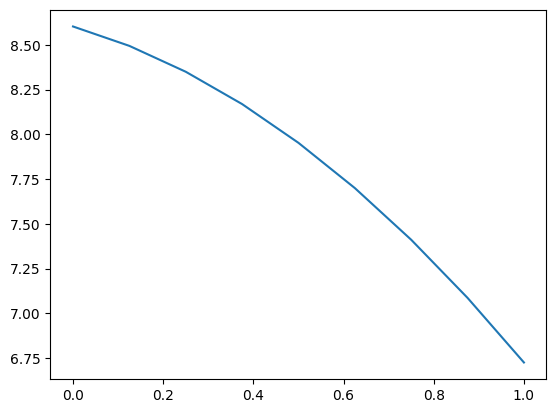

In [34]:
# CELL 8: DFT TARGET TABLE AT ATAT/SQS COMPOSITIONS
# Reconstruction = endpoint baseline + RK excess (totals vs SER, which is
# what an sqs2tdb formation energy should be compared against). Also
# tabulates the GP consensus sigma at each composition for use as the
# convergence-gating threshold (use case B) and fit weights (use case C).
import pandas as pd

x_B_targets = np.array([0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0])
x_A_targets = 1.0 - x_B_targets
elsA, elsB = consensus_data["meta"]["els"]

e_targets = rk_eval(x_B_targets, L_e, ep_e)
s_targets = rk_eval(x_B_targets, L_s, ep_s)
_, sd_e, _, _ = surrogate.predict_with_ensemble_noise(x_B_targets)

# Floor the gate by DFT method/SQS uncertainty. Public TDBs of one system
# often descend from overlapping assessments, so cross-TDB sigma can be
# unrealistically tight (here ~0.3 meV/atom); a converged-DFT + SQS-vs-
# random-alloy error budget of ~5 meV/atom is a sane lower bound. Tune to
# your VASP settings (ENCUT/k-mesh/smearing) and SQS size.
DFT_NOISE_FLOOR_EV = 0.005
sd_gate = np.sqrt(sd_e**2 + DFT_NOISE_FLOOR_EV**2)

results_df = pd.DataFrame({
    f"X({elsA})": x_A_targets,
    f"X({elsB})": x_B_targets,
    f"E_form target ({consensus_data['meta']['units']['E_form']})": np.round(e_targets, 5),
    "gate sigma (eV/atom)": np.round(sd_gate, 5),
    f"svib_ht target ({consensus_data['meta']['units']['svib_ht']})": np.round(s_targets, 4),
})
print(results_df.to_markdown(index=False))
xlo, xhi = ep_e["x_range"]
if np.any((x_B_targets < xlo) | (x_B_targets > xhi)):
    print(f"\nNaN rows: composition outside the phase's modeled range "
          f"[{xlo:.2f}, {xhi:.2f}] — no defensible target exists there; "
          f"do not extrapolate; pick SQS inside the covered range or use "
          f"a different phase's target at those compositions.")
print("\nGate rule (use case B): flag a computed SQS-DFT energy if "
      "|E_DFT - target| > 3 * gate sigma at that composition.")

# plt.plot(x_B_targets, e_targets)
plt.plot(x_B_targets, s_targets)